In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

In [2]:
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
print(df.shape)

(1000, 21)


In [3]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [4]:
df["class"].value_counts()

class
good    700
bad     300
Name: count, dtype: int64

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1000 non-nul

In [6]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [7]:
# Turn the answer into numbers: good = 1, bad = 0
y = (df["class"] == "good").astype(int)

# Everything except the answer column is a clue
X = df.drop(columns=["class"])

# Split clues into numbers vs. words
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print("Number columns:", len(num_cols), num_cols)
print("Word columns:", len(cat_cols), cat_cols)

Number columns: 7 ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Word columns: 13 ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [8]:
X = X.drop(columns=["personal_status"])

In [9]:
# How much is paid per month
X["monthly_payment"] = X["credit_amount"] / X["duration"]

# Is this a long loan (more than 24 months)?
X["is_long_loan"] = (X["duration"] > 24).astype(int)

X[["credit_amount", "duration", "monthly_payment", "is_long_loan"]].head()

,credit_amount,duration,monthly_payment,is_long_loan
0,1169,6,194.833333,0
1,5951,48,123.979167,1
2,2096,12,174.666667,0
3,7882,42,187.666667,1
4,4870,24,202.916667,0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Share of 'good' in train:", round(y_train.mean(), 2))
print("Share of 'good' in test: ", round(y_test.mean(), 2))

Train: (800, 21)  Test: (200, 21)
Share of 'good' in train: 0.7
Share of 'good' in test:  0.7


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# Learn the rules from training data only, then apply them to both sets
X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

print("After preprocessing:", X_train_p.shape)

After preprocessing: (800, 59)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
}

for name, model in models.items():
    model.fit(X_train_p, y_train)
    print(name, "trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

rows = []
for name, model in models.items():
    pred = model.predict(X_test_p)
    proba = model.predict_proba(X_test_p)[:, 1]
    rows.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.847,0.671,0.749,0.748
Decision Tree,0.844,0.579,0.686,0.696
Random Forest,0.831,0.771,0.800,0.784


In [14]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test_p))
    print(name)
    print(pd.DataFrame(cm, index=["Actually bad", "Actually good"],
                       columns=["Predicted bad", "Predicted good"]))
    print()

Logistic Regression
               Predicted bad  Predicted good
Actually bad              43              17
Actually good             46              94

Decision Tree
               Predicted bad  Predicted good
Actually bad              45              15
Actually good             59              81

Random Forest
               Predicted bad  Predicted good
Actually bad              38              22
Actually good             32             108



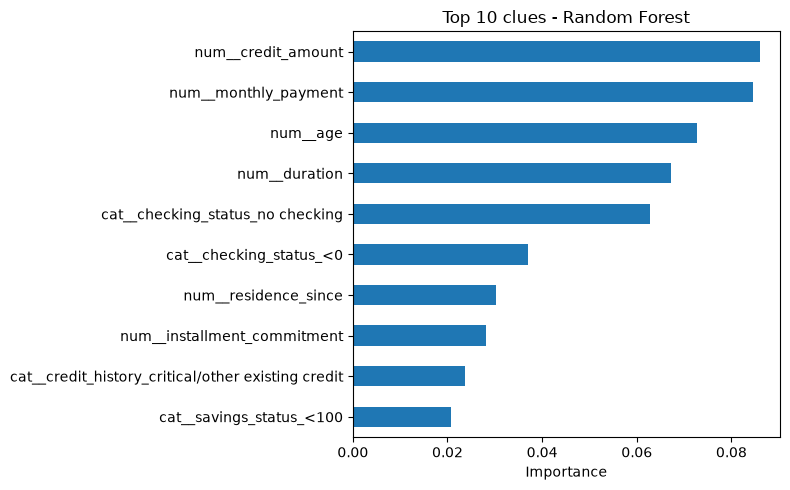

In [15]:
import matplotlib.pyplot as plt

names = preprocess.get_feature_names_out()
rf = models["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False).head(10)

importance.sort_values().plot(kind="barh", figsize=(8, 5), title="Top 10 clues - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

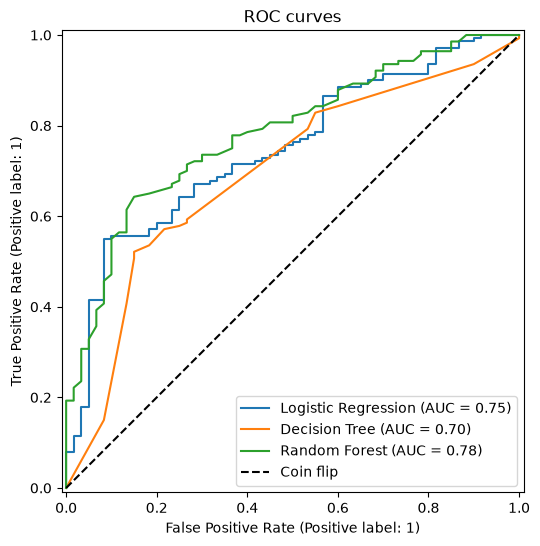

In [16]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_p, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Coin flip")
ax.legend()
plt.title("ROC curves")
plt.show()